<a href="https://colab.research.google.com/github/sanjanabalan84-glitch/ML-AI-PROJECT/blob/main/Day_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [2]:
#ANN
iris=sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
le=LabelEncoder()
iris['species']=le.fit_transform(iris['species'])
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
iris.shape

(150, 5)

In [5]:
x=iris.drop(columns=['species'])
y=iris['species']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=12)
x_train.shape

(112, 4)

In [6]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [7]:
model=Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(10,activation='relu'))  #relu hidden layers
model.add(Dense(3,activation='softmax')) #softmax output layers


In [8]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))
loss,accuracy=model.evaluate(x_test,y_test)
print(f'Loss:{loss}')   #print("test accuracy",accuracy)
print(f'accuracy:{accuracy}')


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.4839 - loss: 1.0971 - val_accuracy: 0.5789 - val_loss: 1.0229
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4963 - loss: 1.0541 - val_accuracy: 0.5789 - val_loss: 0.9901
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4984 - loss: 1.0323 - val_accuracy: 0.6316 - val_loss: 0.9580
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4520 - loss: 0.9894 - val_accuracy: 0.6842 - val_loss: 0.9271
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4757 - loss: 0.9651 - val_accuracy: 0.6842 - val_loss: 0.8971
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5149 - loss: 0.9469 - val_accuracy: 0.6316 - val_loss: 0.8668
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4922 - loss: 0.9223 - val_accuracy: 0.6316 - val_loss: 0.8356
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5980 - loss: 0.8957 - val_accuracy: 0.

In [9]:
predictions=model.predict(x_test)
predicted_class=np.argmax(predictions,axis=1)
predicted_class

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([0, 2, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 0, 0, 1, 2, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 2, 2, 1, 0, 0, 0, 1, 2, 0, 2, 0, 1, 1])

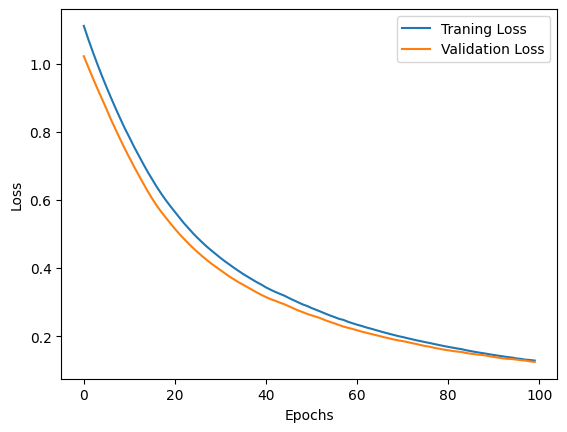

In [10]:
plt.plot(learned.history['loss'],label='Traning Loss')
plt.plot(learned.history['val_loss'],label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [11]:
new_data=np.array([[5.1,3.5,1.4,0.2],
                  [6.0,2.7,4.2,1.3]])

new_data=scaler.transform(new_data)
predictions=model.predict(new_data)
predicted_class=np.argmax(predictions,axis=1)
predicted_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0, 1])

In [14]:
df=pd.read_csv('/content/Copy of breastcancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [15]:
df.shape

(569, 33)

In [16]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [18]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [19]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [20]:
data=df.drop(columns=['id','Unnamed: 32'])
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [21]:
le=LabelEncoder()
data['diagnosis']=le.fit_transform(data['diagnosis'])
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


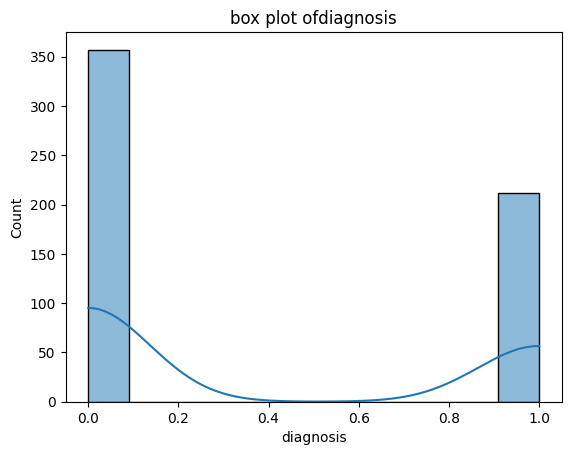

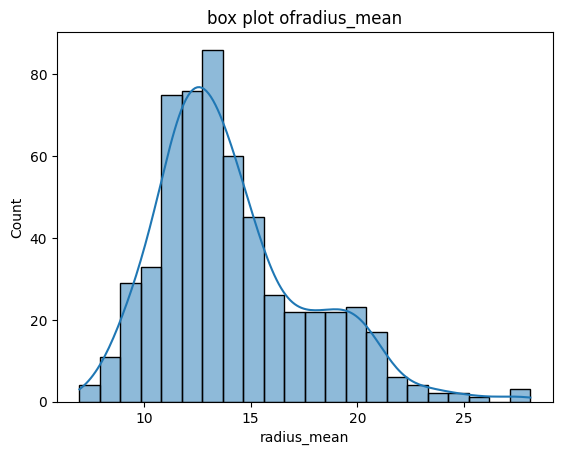

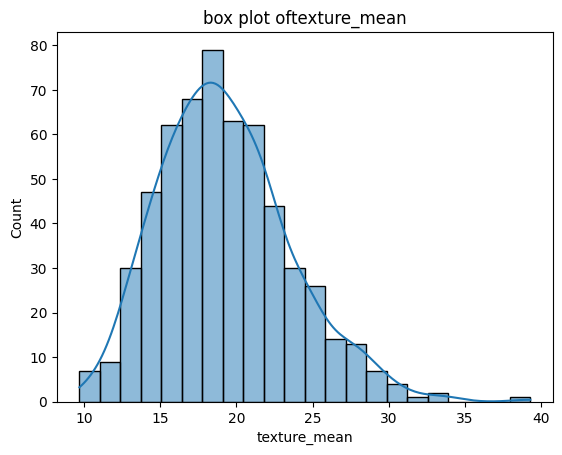

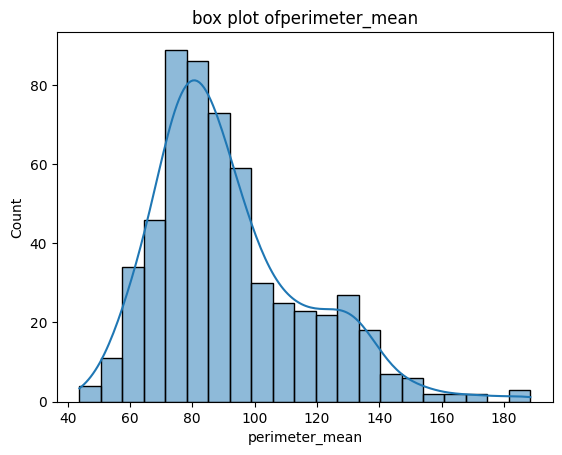

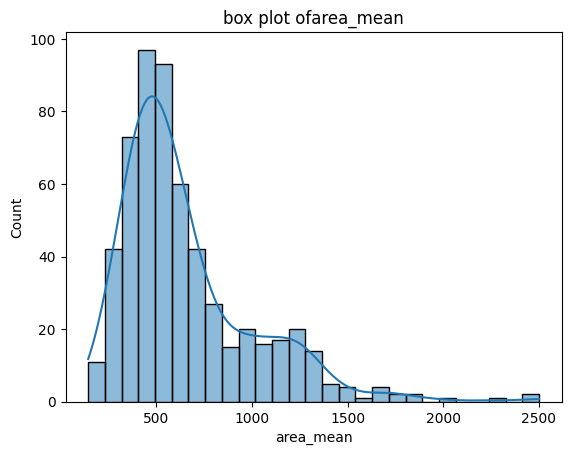

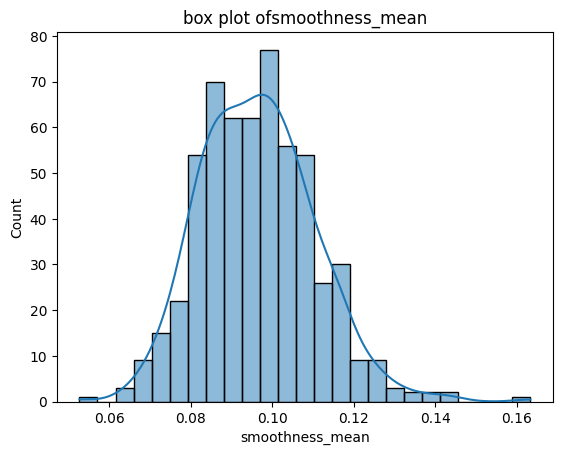

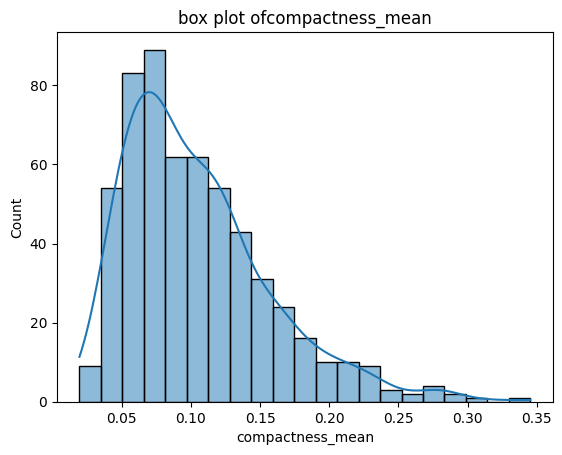

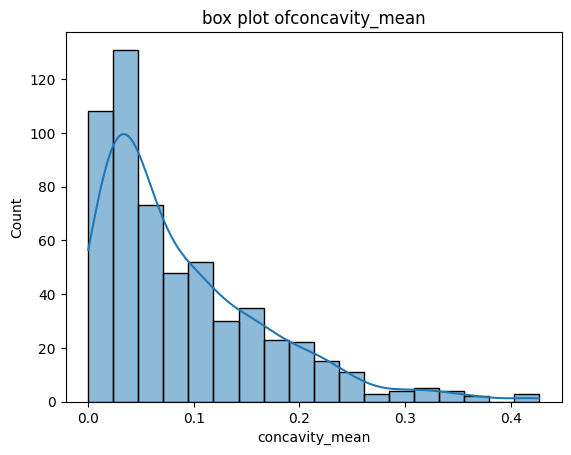

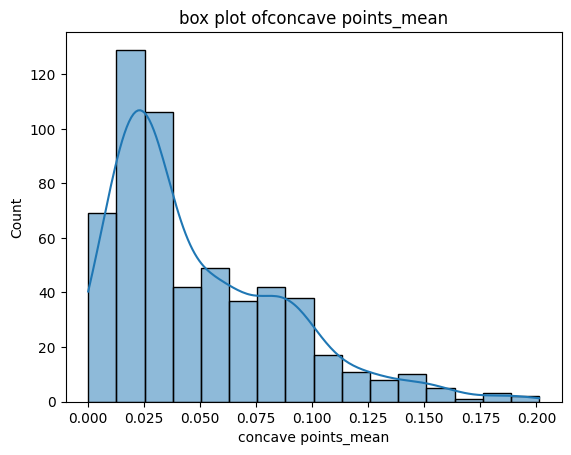

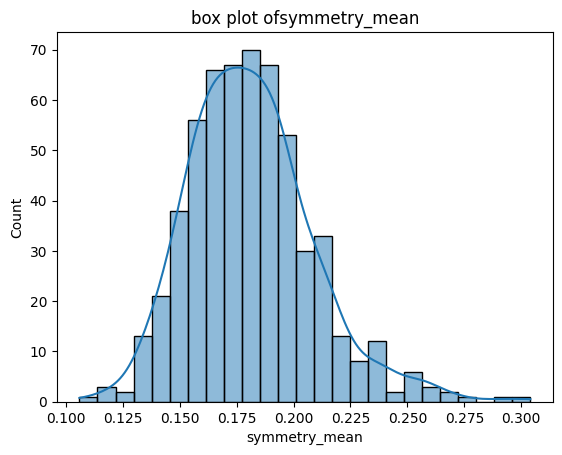

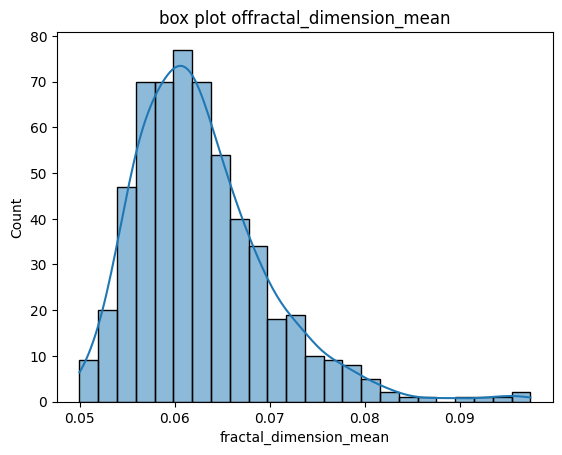

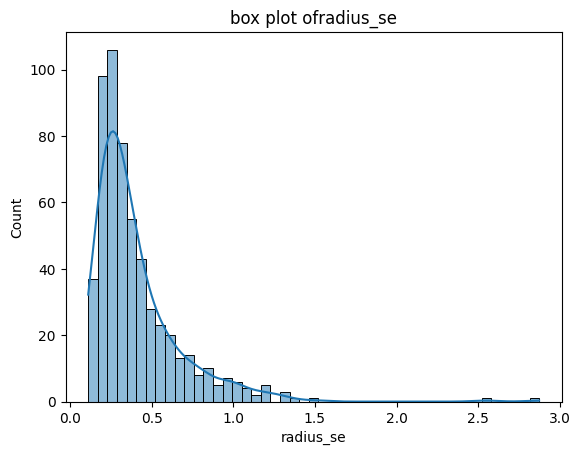

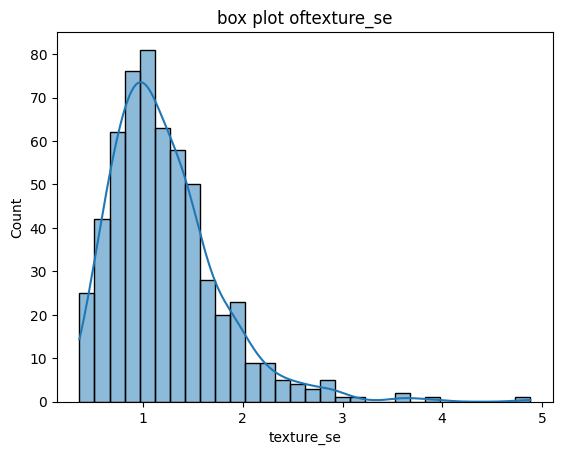

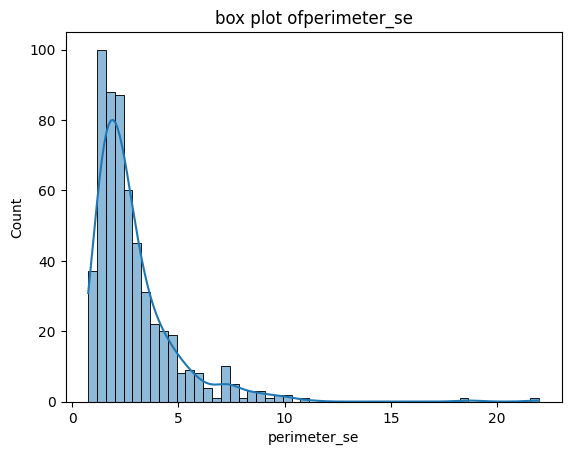

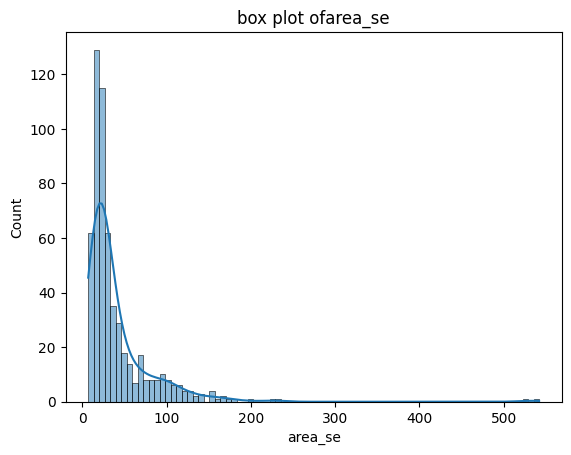

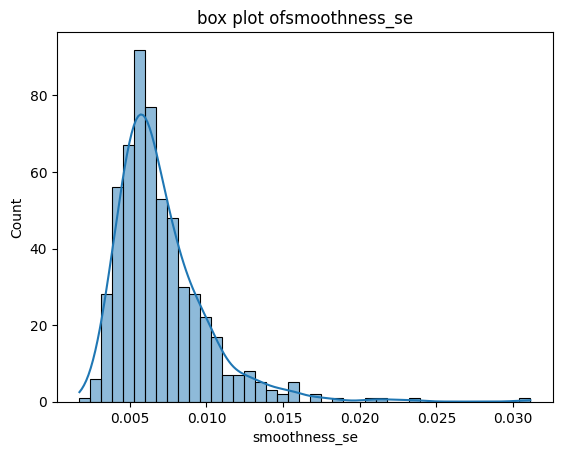

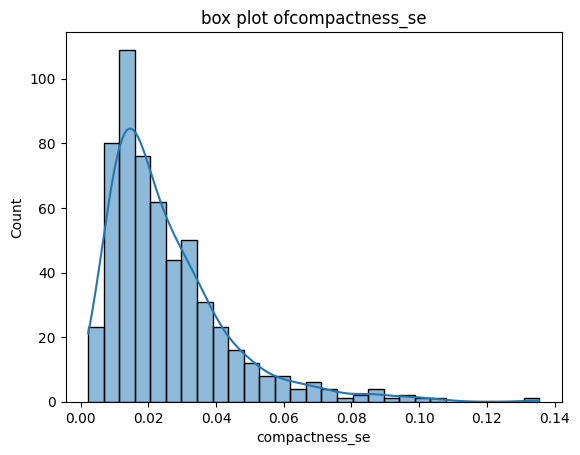

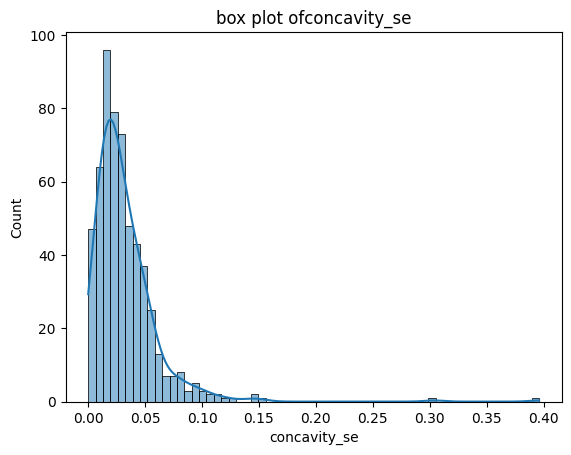

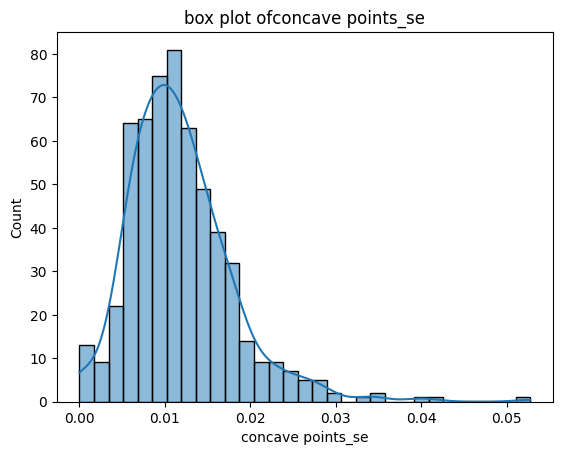

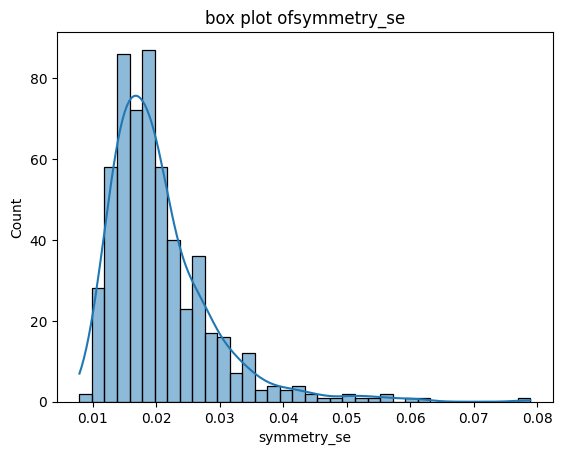

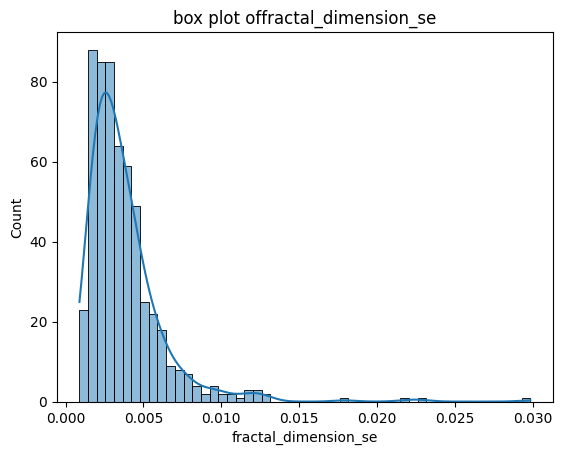

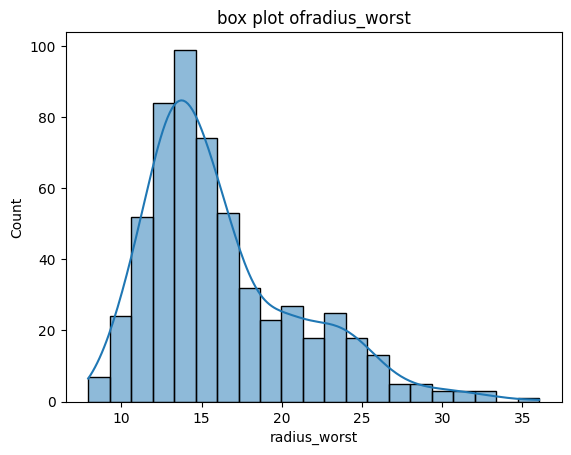

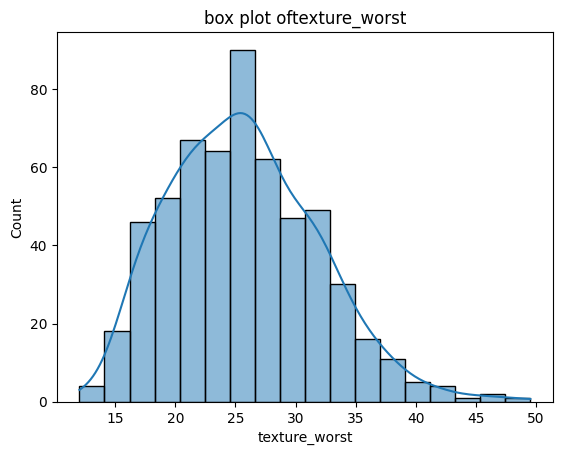

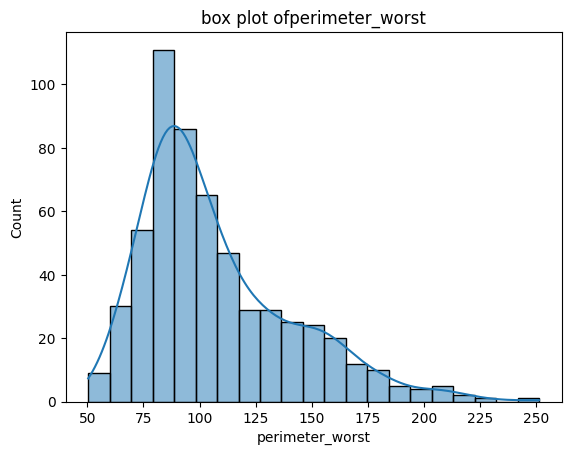

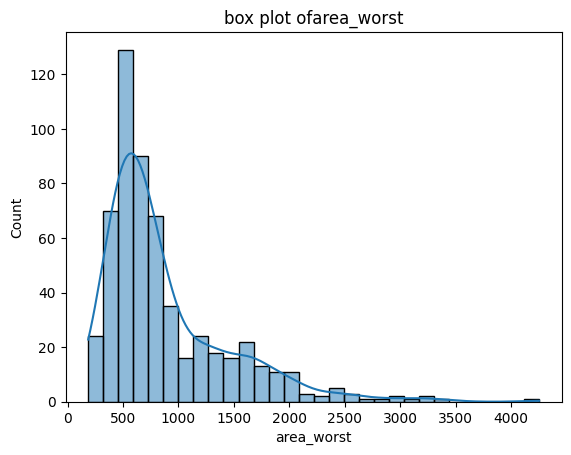

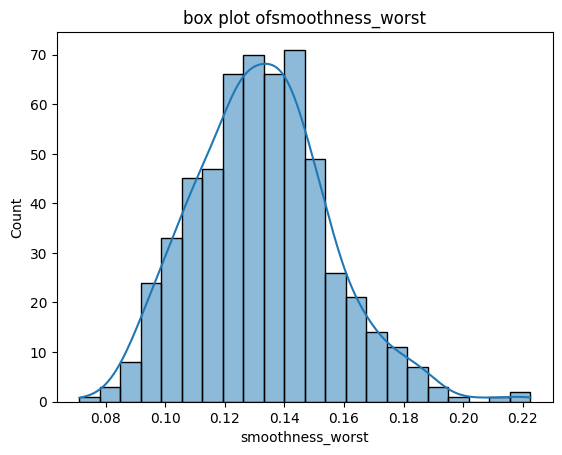

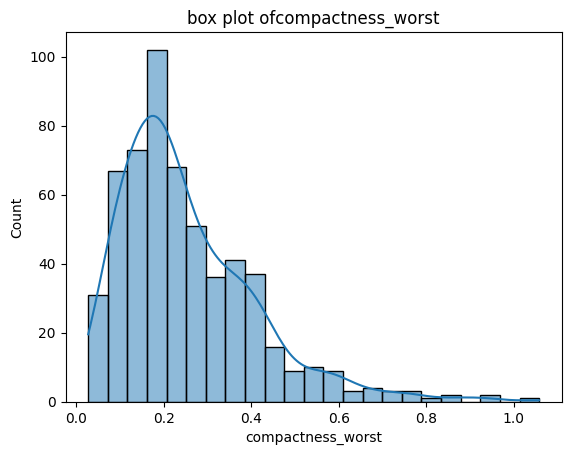

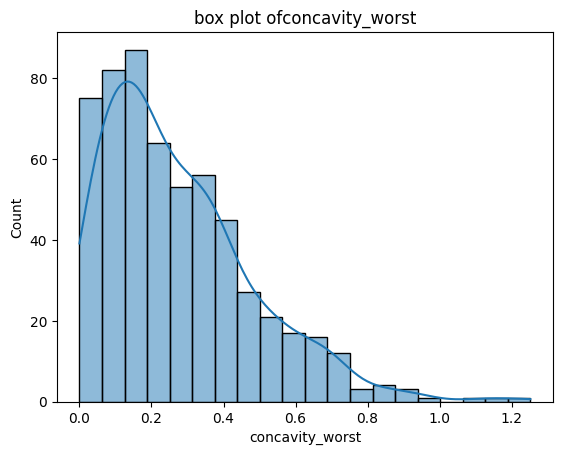

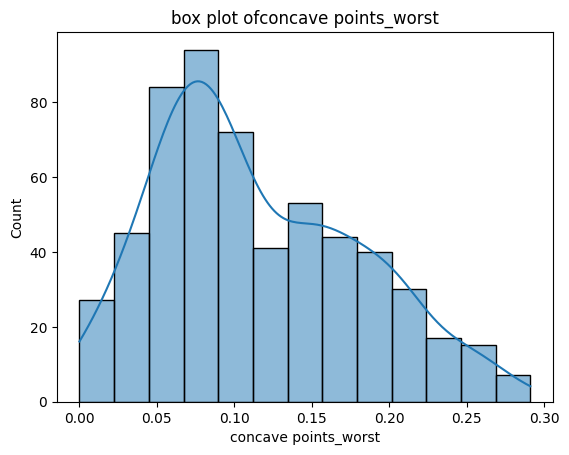

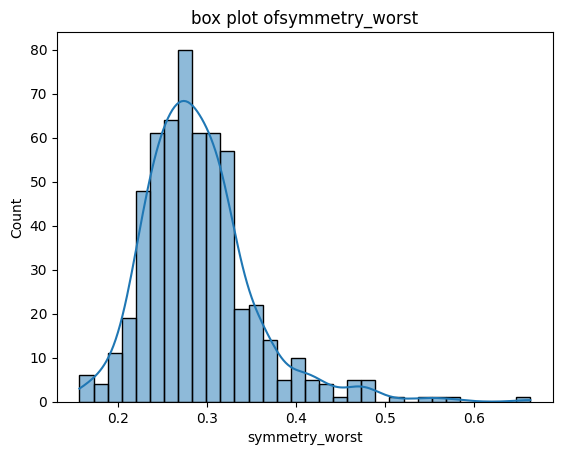

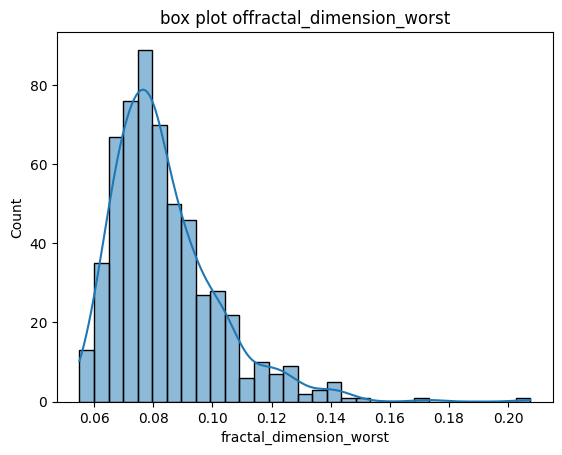

In [22]:
numerical_cols=data.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
    sns.histplot(data[col],kde=True)
    plt.title(f"box plot of{col}")
    plt.show()

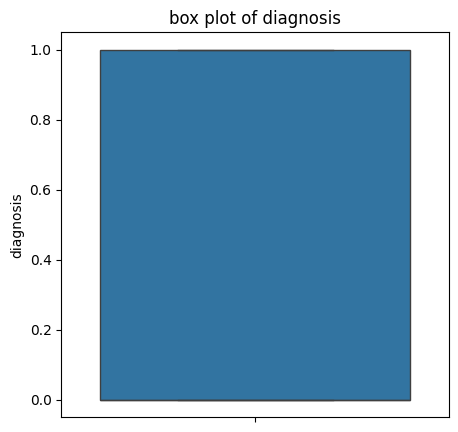

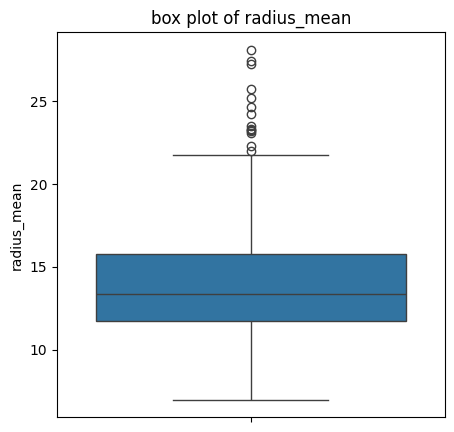

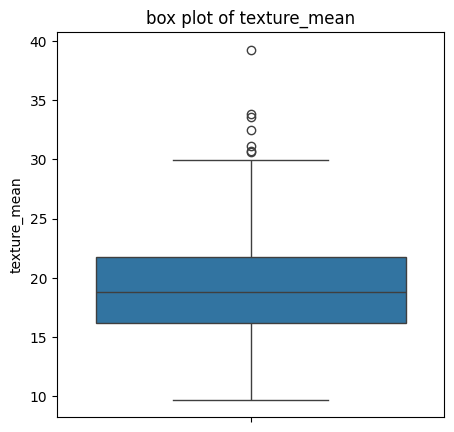

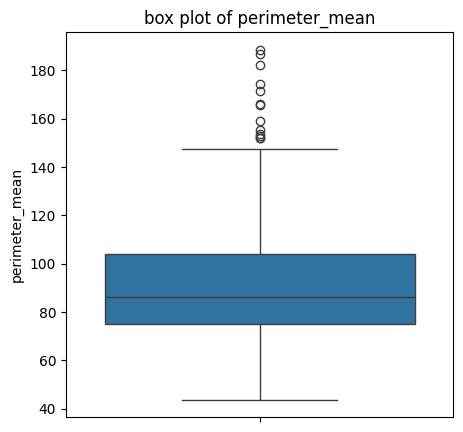

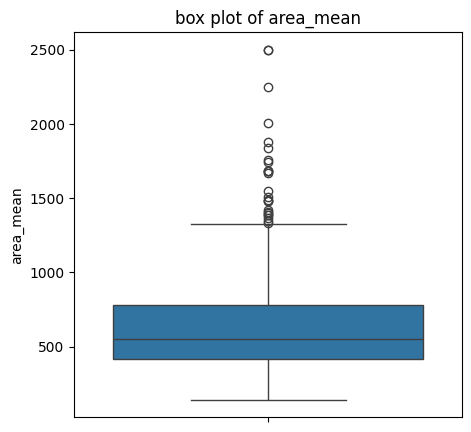

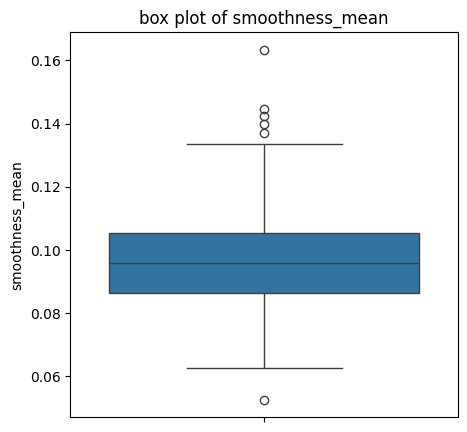

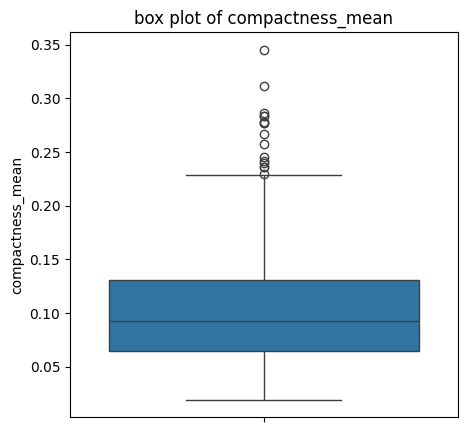

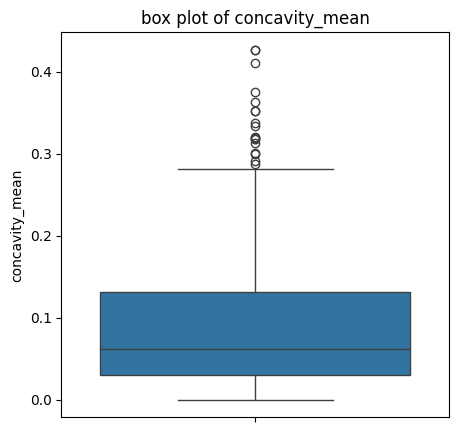

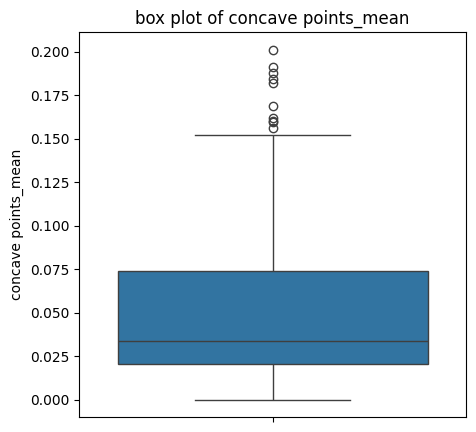

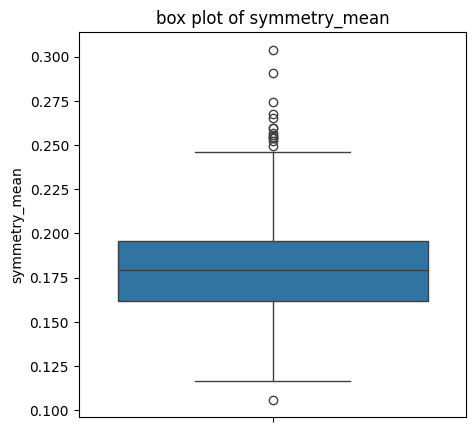

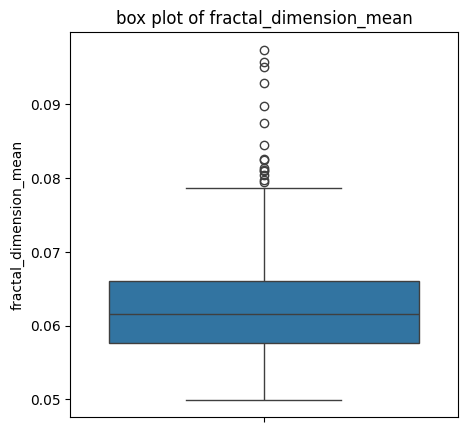

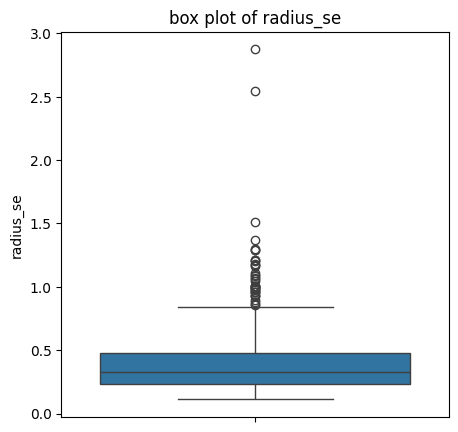

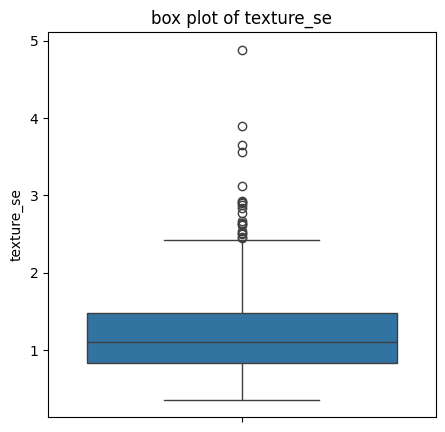

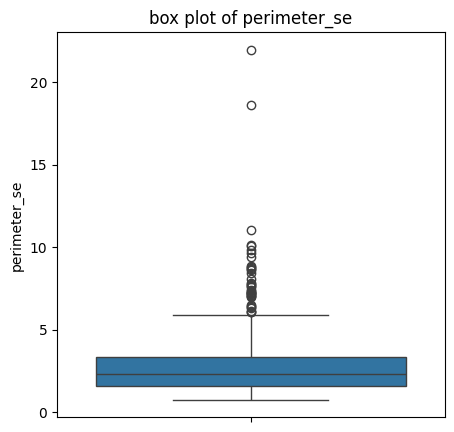

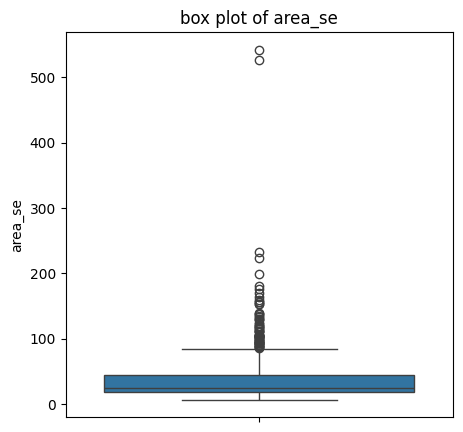

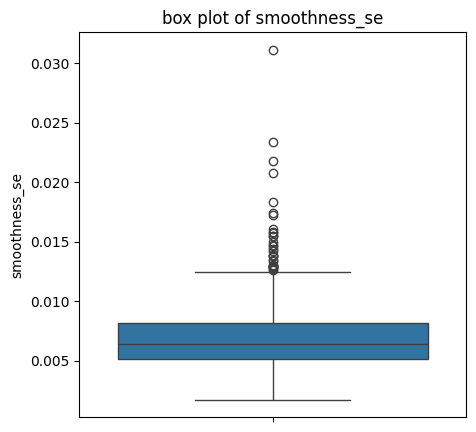

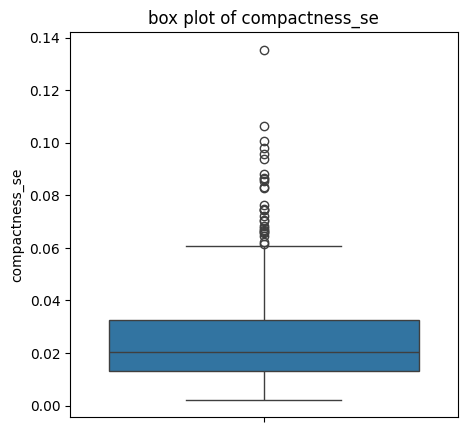

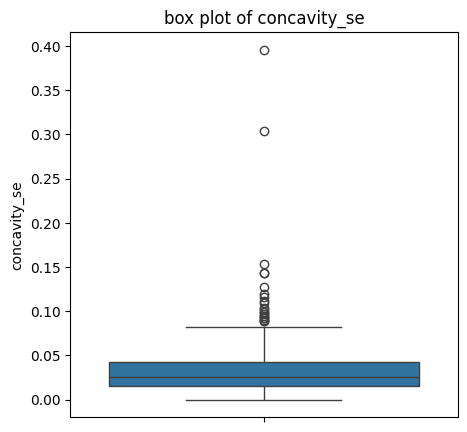

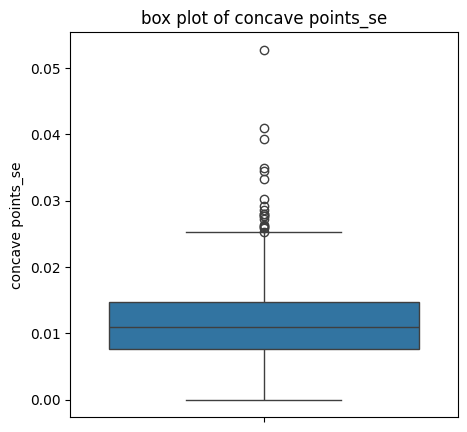

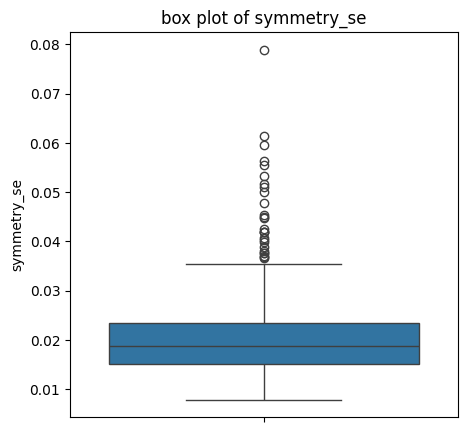

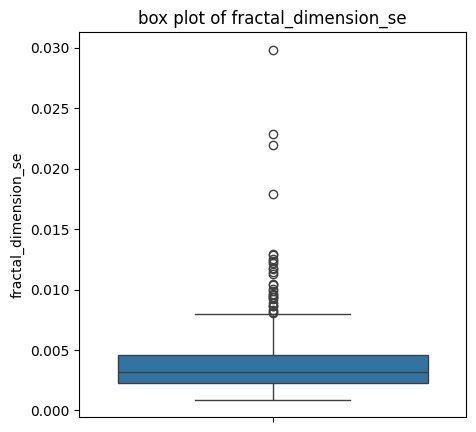

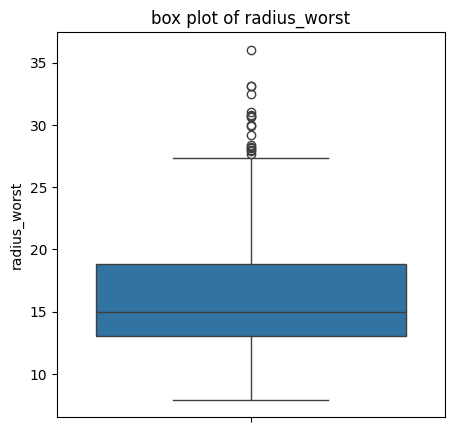

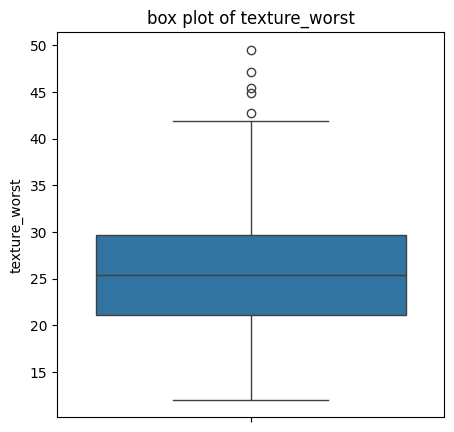

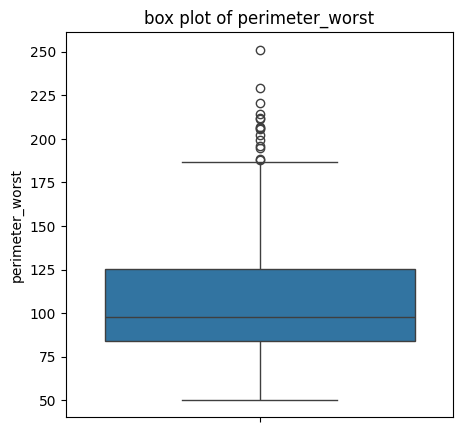

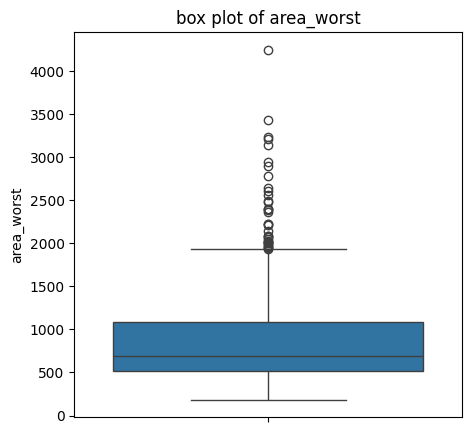

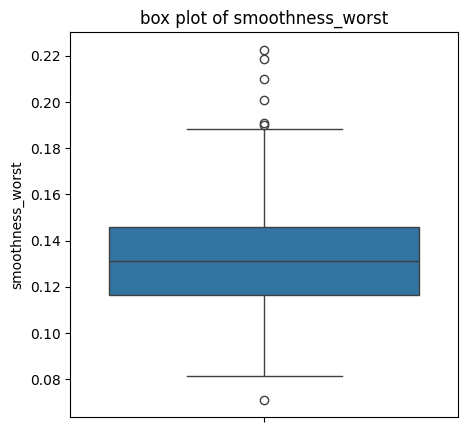

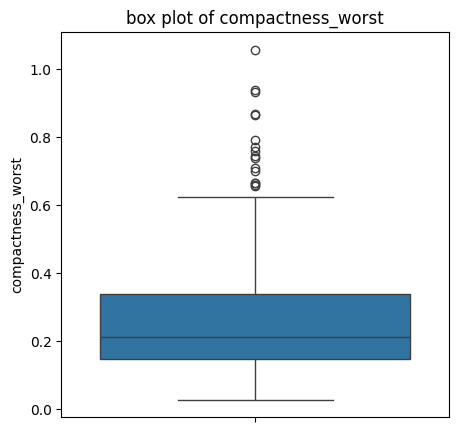

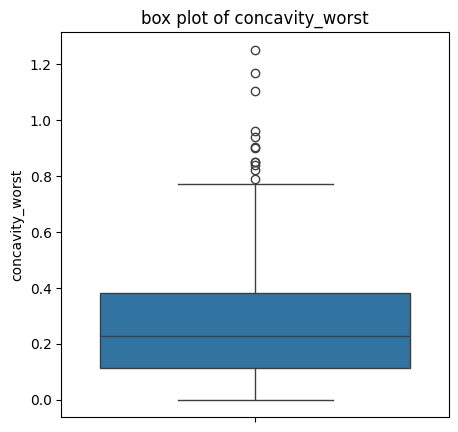

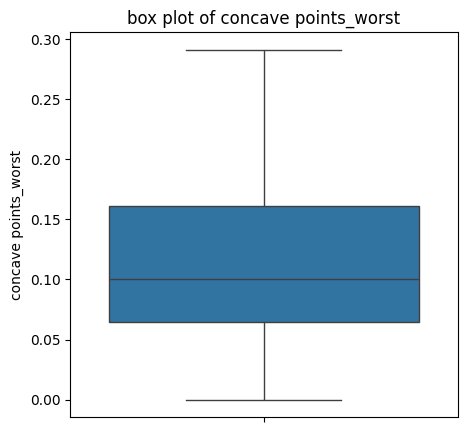

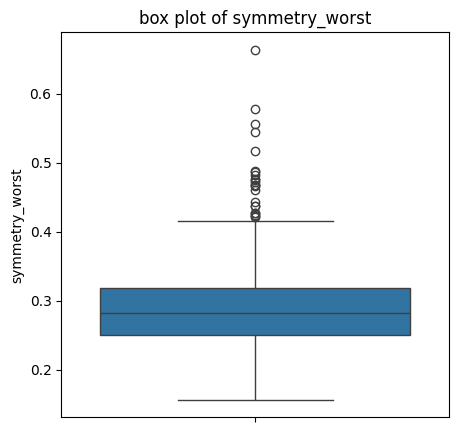

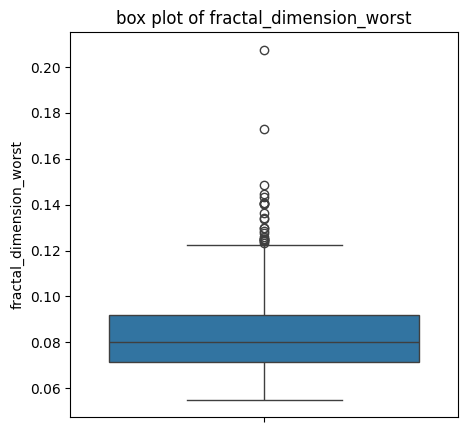

In [23]:
numerical_cols=data.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(y=data[col])
  plt.title(f'box plot of {col}')
  plt.show()

In [24]:
from scipy.stats import skew
skew_values=data[numerical_cols].skew()
print(skew_values)

diagnosis                  0.528461
radius_mean                0.942380
texture_mean               0.650450
perimeter_mean             0.990650
area_mean                  1.645732
smoothness_mean            0.456324
compactness_mean           1.190123
concavity_mean             1.401180
concave points_mean        1.171180
symmetry_mean              0.725609
fractal_dimension_mean     1.304489
radius_se                  3.088612
texture_se                 1.646444
perimeter_se               3.443615
area_se                    5.447186
smoothness_se              2.314450
compactness_se             1.902221
concavity_se               5.110463
concave points_se          1.444678
symmetry_se                2.195133
fractal_dimension_se       3.923969
radius_worst               1.103115
texture_worst              0.498321
perimeter_worst            1.128164
area_worst                 1.859373
smoothness_worst           0.415426
compactness_worst          1.473555
concavity_worst            1

In [25]:
y=data['diagnosis']
x=data.drop(['diagnosis'],axis=1)

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [27]:
x_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
287,12.89,13.12,81.89,515.9,0.06955,0.03729,0.02260,0.01171,0.1337,0.05581,...,13.62,15.54,87.40,577.0,0.09616,0.1147,0.1186,0.05366,0.2309,0.06915
512,13.40,20.52,88.64,556.7,0.11060,0.14690,0.14450,0.08172,0.2116,0.07325,...,16.41,29.66,113.30,844.4,0.15740,0.3856,0.5106,0.20510,0.3585,0.11090
402,12.96,18.29,84.18,525.2,0.07351,0.07899,0.04057,0.01883,0.1874,0.05899,...,14.13,24.61,96.31,621.9,0.09329,0.2318,0.1604,0.06608,0.3207,0.07247
446,17.75,28.03,117.30,981.6,0.09997,0.13140,0.16980,0.08293,0.1713,0.05916,...,21.53,38.54,145.40,1437.0,0.14010,0.3762,0.6399,0.19700,0.2972,0.09075
210,20.58,22.14,134.70,1290.0,0.09090,0.13480,0.16400,0.09561,0.1765,0.05024,...,23.24,27.84,158.30,1656.0,0.11780,0.2920,0.3861,0.19200,0.2909,0.05865


In [28]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [29]:
model=Sequential()
model.add(Input(shape=(30,)))
model.add(Dense(10,activation='relu'))  #relu hidden layers
model.add(Dense(3,activation='sigmoid')) #softmax output layers


In [30]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))
loss,accuracy=model.evaluate(x_test,y_test)
print(f'Loss:{loss}')   #print("test accuracy",accuracy)
print(f'accuracy:{accuracy}')


Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4289 - loss: 1.1596 - val_accuracy: 0.6643 - val_loss: 0.8176
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7261 - loss: 0.6727 - val_accuracy: 0.8951 - val_loss: 0.5095
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8940 - loss: 0.4846 - val_accuracy: 0.9580 - val_loss: 0.3439
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9392 - loss: 0.3253 - val_accuracy: 0.9580 - val_loss: 0.2544
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9555 - loss: 0.2505 - val_accuracy: 0.9720 - val_loss: 0.1993
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9339 - loss: 0.2440 - val_accuracy: 0.9720 - val_loss: 0.1651
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9455 - loss: 0.1954 - val_accuracy: 0.9720 - val_loss: 0.1406
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9576 - loss: 0.1715 - val_accuracy: 0.9790 - v

In [31]:
predictions=model.predict(x_test)
predicted_class=np.argmax(predictions,axis=1)
predicted_class

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0])

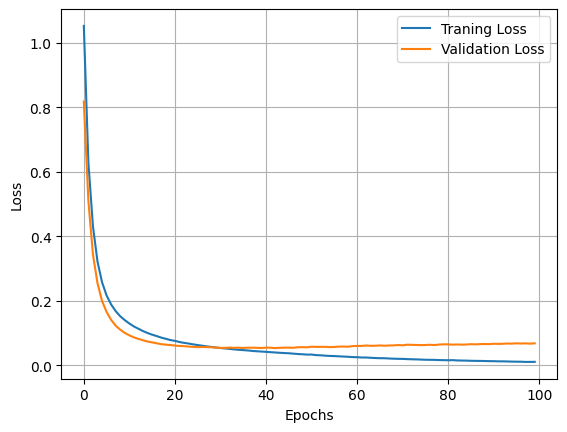

In [32]:
plt.plot(learned.history['loss'],label='Traning Loss')
plt.plot(learned.history['val_loss'],label='Validation Loss')
plt.legend()
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [33]:
df=sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [34]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [35]:
df.shape

(344, 7)

In [36]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [38]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [39]:
df['sex']=df['sex'].fillna(df['sex'].mode())
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [41]:
df['bill_length_mm']=df['bill_length_mm'].fillna(df['bill_length_mm'].mean())
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.50000,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.30000,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,43.92193,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.70000,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.80000,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.40000,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.20000,14.8,212.0,5200.0,Female


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     344 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [43]:
df['bill_depth_mm']=df['bill_depth_mm'].fillna(df['bill_depth_mm'].mean())
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.0,3750.0,Male
1,Adelie,Torgersen,39.50000,17.40000,186.0,3800.0,Female
2,Adelie,Torgersen,40.30000,18.00000,195.0,3250.0,Female
3,Adelie,Torgersen,43.92193,17.15117,NaN,NaN,NaN
4,Adelie,Torgersen,36.70000,19.30000,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,NaN,NaN,NaN
340,Gentoo,Biscoe,46.80000,14.30000,215.0,4850.0,Female
341,Gentoo,Biscoe,50.40000,15.70000,222.0,5750.0,Male
342,Gentoo,Biscoe,45.20000,14.80000,212.0,5200.0,Female


In [44]:
df['flipper_length_mm']=df['flipper_length_mm'].fillna(df['flipper_length_mm'].mean())
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.0,Male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.0,Female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.0,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,NaN,NaN
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,NaN,NaN
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.0,Female
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.0,Male
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.0,Female


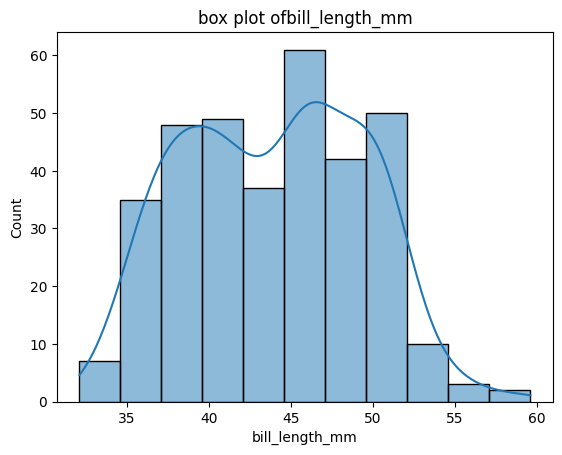

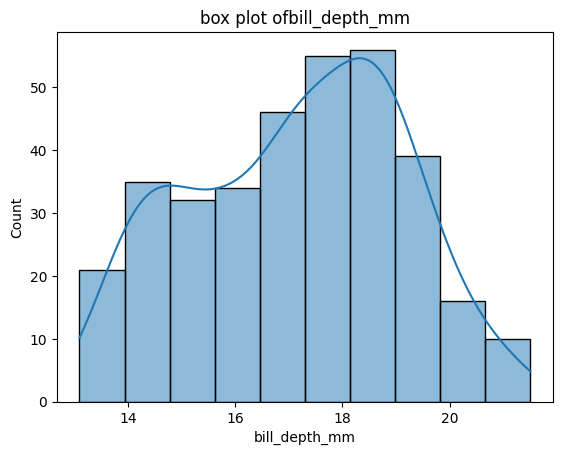

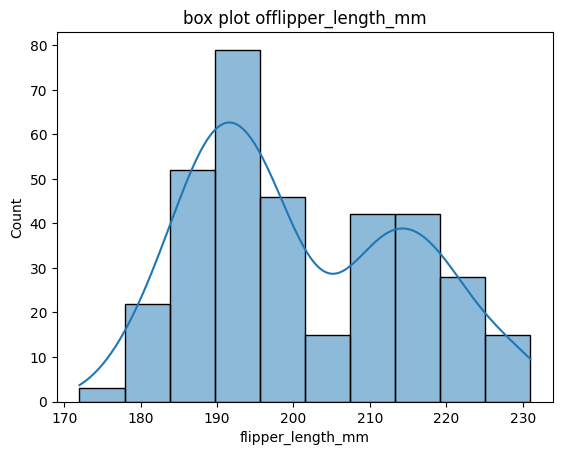

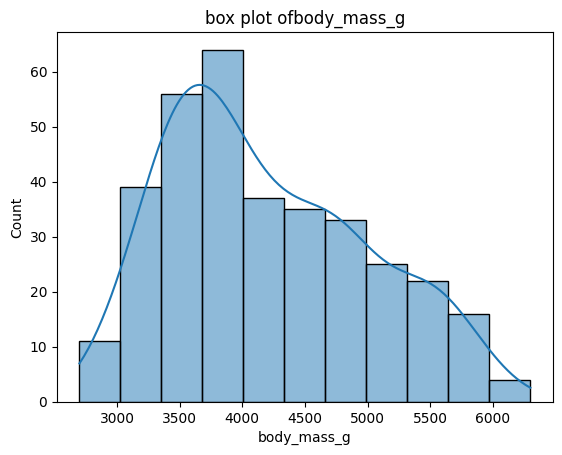

In [45]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
    sns.histplot(df[col],kde=True)
    plt.title(f"box plot of{col}")
    plt.show()

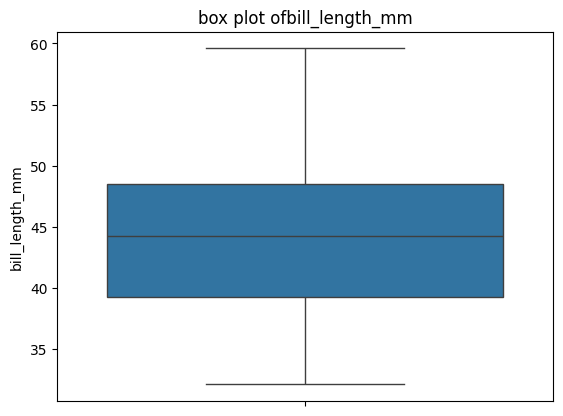

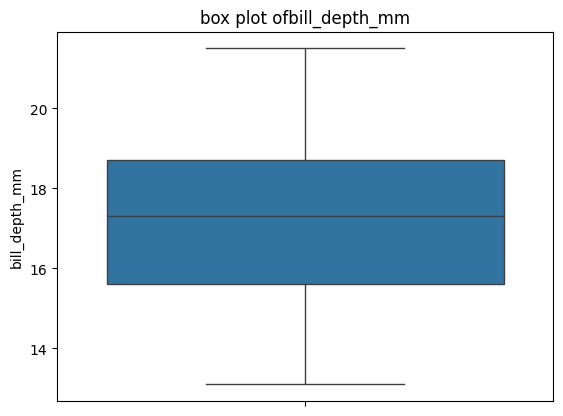

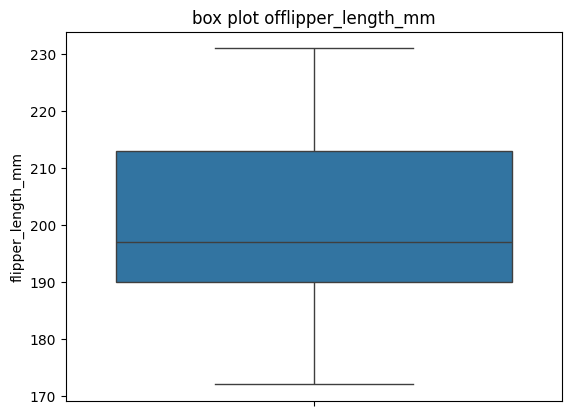

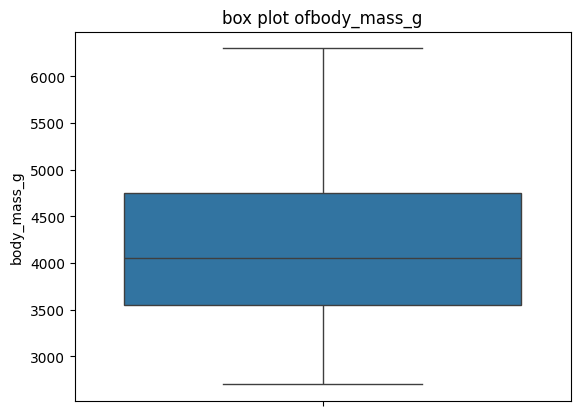

In [46]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
    sns.boxplot(df[col])
    plt.title(f"box plot of{col}")
    plt.show()

In [47]:
from scipy.stats import skew
skew_values=df[numerical_cols].skew()
print(skew_values)

bill_length_mm       0.053272
bill_depth_mm       -0.143880
flipper_length_mm    0.346682
body_mass_g          0.470329
dtype: float64


In [48]:
df['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [49]:
df=pd.get_dummies(df,columns=["species"],prefix="species",drop_first=True)
df.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_Chinstrap,species_Gentoo
0,Torgersen,39.10000,18.70000,181.000000,3750.0,Male,False,False
1,Torgersen,39.50000,17.40000,186.000000,3800.0,Female,False,False
2,Torgersen,40.30000,18.00000,195.000000,3250.0,Female,False,False
3,Torgersen,43.92193,17.15117,200.915205,NaN,NaN,False,False
4,Torgersen,36.70000,19.30000,193.000000,3450.0,Female,False,False


In [50]:
bool_col=df.select_dtypes(include='bool').columns
df[bool_col]=df[bool_col].astype(int)
df

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_Chinstrap,species_Gentoo
0,Torgersen,39.10000,18.70000,181.000000,3750.0,Male,0,0
1,Torgersen,39.50000,17.40000,186.000000,3800.0,Female,0,0
2,Torgersen,40.30000,18.00000,195.000000,3250.0,Female,0,0
3,Torgersen,43.92193,17.15117,200.915205,NaN,NaN,0,0
4,Torgersen,36.70000,19.30000,193.000000,3450.0,Female,0,0
...,...,...,...,...,...,...,...,...
339,Biscoe,43.92193,17.15117,200.915205,NaN,NaN,0,1
340,Biscoe,46.80000,14.30000,215.000000,4850.0,Female,0,1
341,Biscoe,50.40000,15.70000,222.000000,5750.0,Male,0,1
342,Biscoe,45.20000,14.80000,212.000000,5200.0,Female,0,1


In [51]:
df=pd.get_dummies(df,columns=["island"],prefix="island",drop_first=True)
df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen
0,39.10000,18.70000,181.000000,3750.0,Male,0,0,False,True
1,39.50000,17.40000,186.000000,3800.0,Female,0,0,False,True
2,40.30000,18.00000,195.000000,3250.0,Female,0,0,False,True
3,43.92193,17.15117,200.915205,NaN,NaN,0,0,False,True
4,36.70000,19.30000,193.000000,3450.0,Female,0,0,False,True


In [52]:
bool_col=df.select_dtypes(include='bool').columns
df[bool_col]=df[bool_col].astype(int)
df

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen
0,39.10000,18.70000,181.000000,3750.0,Male,0,0,0,1
1,39.50000,17.40000,186.000000,3800.0,Female,0,0,0,1
2,40.30000,18.00000,195.000000,3250.0,Female,0,0,0,1
3,43.92193,17.15117,200.915205,NaN,NaN,0,0,0,1
4,36.70000,19.30000,193.000000,3450.0,Female,0,0,0,1
...,...,...,...,...,...,...,...,...,...
339,43.92193,17.15117,200.915205,NaN,NaN,0,1,0,0
340,46.80000,14.30000,215.000000,4850.0,Female,0,1,0,0
341,50.40000,15.70000,222.000000,5750.0,Male,0,1,0,0
342,45.20000,14.80000,212.000000,5200.0,Female,0,1,0,0


In [53]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['sex']=le.fit_transform(df["sex"])
df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen
0,39.10000,18.70000,181.000000,3750.0,1,0,0,0,1
1,39.50000,17.40000,186.000000,3800.0,0,0,0,0,1
2,40.30000,18.00000,195.000000,3250.0,0,0,0,0,1
3,43.92193,17.15117,200.915205,NaN,2,0,0,0,1
4,36.70000,19.30000,193.000000,3450.0,0,0,0,0,1


In [54]:
df_cleaned=df.dropna(subset=['body_mass_g'])
df_cleaned.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen
0,39.1,18.7,181.0,3750.0,1,0,0,0,1
1,39.5,17.4,186.0,3800.0,0,0,0,0,1
2,40.3,18.0,195.0,3250.0,0,0,0,0,1
4,36.7,19.3,193.0,3450.0,0,0,0,0,1
5,39.3,20.6,190.0,3650.0,1,0,0,0,1


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     344 non-null    float64
 1   bill_depth_mm      344 non-null    float64
 2   flipper_length_mm  344 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                344 non-null    int64  
 5   species_Chinstrap  344 non-null    int64  
 6   species_Gentoo     344 non-null    int64  
 7   island_Dream       344 non-null    int64  
 8   island_Torgersen   344 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 24.3 KB


In [56]:
y=df_cleaned['body_mass_g']
x=df_cleaned.drop(columns=['body_mass_g'],axis=1)

In [57]:
df

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen
0,39.10000,18.70000,181.000000,3750.0,1,0,0,0,1
1,39.50000,17.40000,186.000000,3800.0,0,0,0,0,1
2,40.30000,18.00000,195.000000,3250.0,0,0,0,0,1
3,43.92193,17.15117,200.915205,NaN,2,0,0,0,1
4,36.70000,19.30000,193.000000,3450.0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...
339,43.92193,17.15117,200.915205,NaN,2,0,1,0,0
340,46.80000,14.30000,215.000000,4850.0,0,0,1,0,0
341,50.40000,15.70000,222.000000,5750.0,1,0,1,0,0
342,45.20000,14.80000,212.000000,5200.0,0,0,1,0,0


In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [59]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen
0,39.10000,18.70000,181.000000,3750.0,1,0,0,0,1
1,39.50000,17.40000,186.000000,3800.0,0,0,0,0,1
2,40.30000,18.00000,195.000000,3250.0,0,0,0,0,1
3,43.92193,17.15117,200.915205,NaN,2,0,0,0,1
4,36.70000,19.30000,193.000000,3450.0,0,0,0,0,1


In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [61]:
model=Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(32,activation='relu'))  #relu hidden layers only uses for regression
model.add(Dense(16,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='linear')) #output layer

In [78]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae','mse','r2_score'])
learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))
loss,mae,mse,r2=model.evaluate(x_test,y_test)
print('test loss:',loss)
print('test mae:',mae)
print('test mse:',mse)
print('test r2:',r2)


Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 95270.0000 - mae: 246.4761 - mse: 95270.0000 - r2_score: 0.8058 - val_loss: 140855.5625 - val_mae: 286.1182 - val_mse: 140855.5625 - val_r2_score: 0.8016
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 96039.4297 - mae: 245.0935 - mse: 96039.4297 - r2_score: 0.8446 - val_loss: 138584.1094 - val_mae: 287.6671 - val_mse: 138584.1094 - val_r2_score: 0.8048
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 92091.6797 - mae: 248.0343 - mse: 92091.6875 - r2_score: 0.8561 - val_loss: 137146.2500 - val_mae: 286.6068 - val_mse: 137146.2500 - val_r2_score: 0.8069
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 102594.3984 - mae: 252.6496 - mse: 102594.3984 - r2_score: 0.8415 - val_loss: 137336.4062 - val_mae: 285.5238 - val_mse: 137336.4062 - val_r2_score: 0.8066
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 88604.8672 - mae: 241.6370 - mse: 88604.8672 - r2_score: 0.8525 - val_loss: 139638.359

In [79]:
predictions=model.predict(x_test)
predicted_class

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

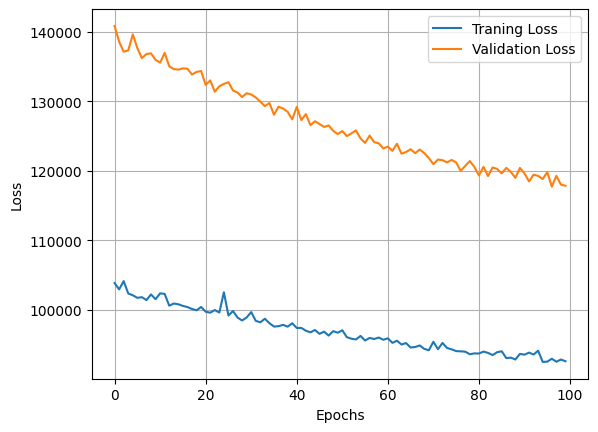

In [80]:
plt.plot(learned.history['loss'],label='Traning Loss')
plt.plot(learned.history['val_loss'],label='Validation Loss')
plt.legend()
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [68]:
y_train.value_counts()

,count
body_mass_g,
3800.0,11
3950.0,10
3700.0,8
3900.0,7
4050.0,6
...,...
5600.0,1
4375.0,1
2700.0,1


In [69]:
df1=sns.load_dataset('diamonds')
df1.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [70]:
df1.shape

(53940, 10)

In [71]:
df1.size

539400

In [72]:
df1.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [73]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [74]:
df1.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


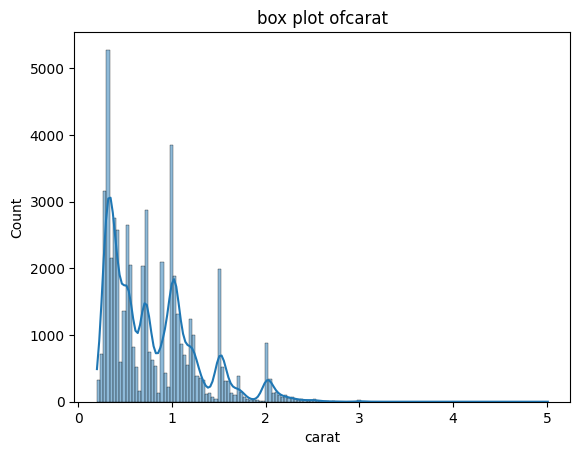

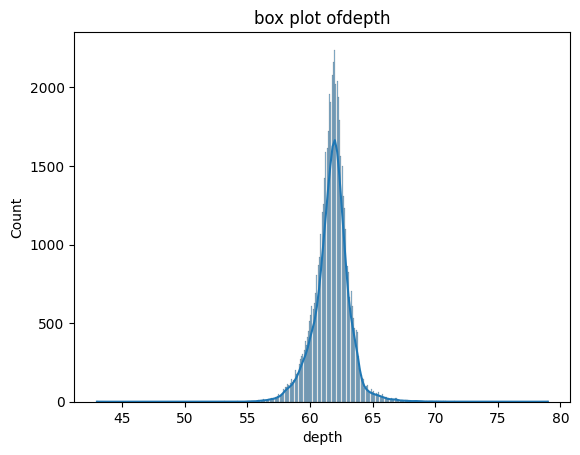

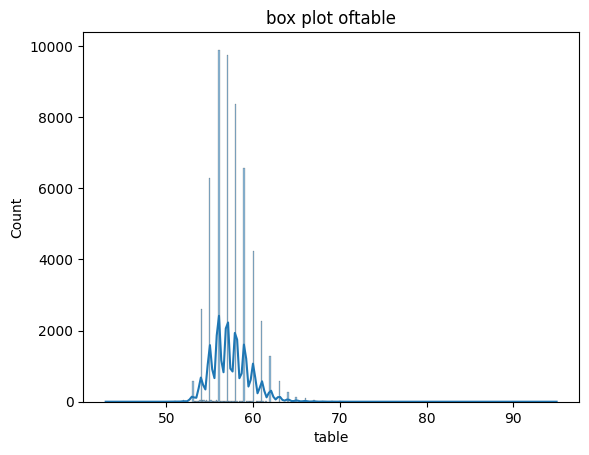

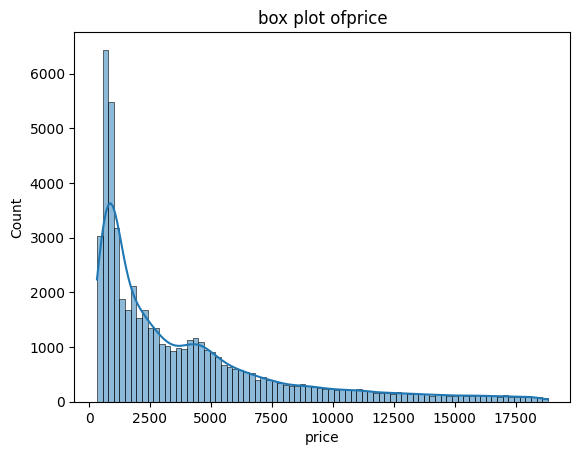

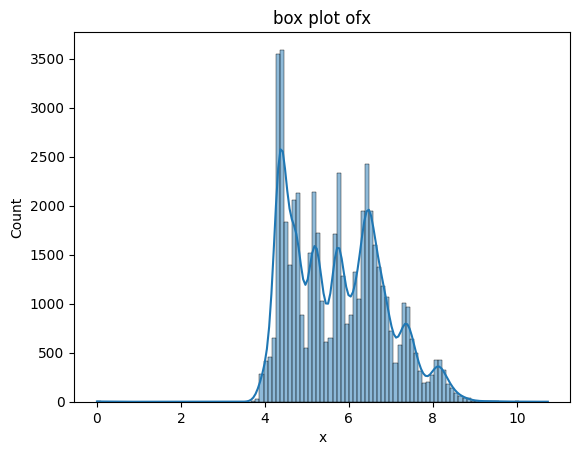

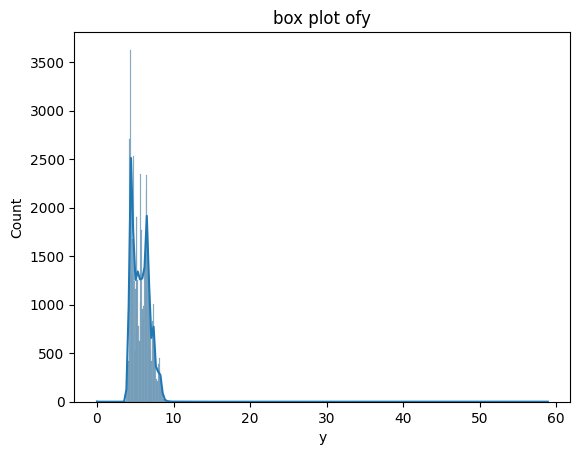

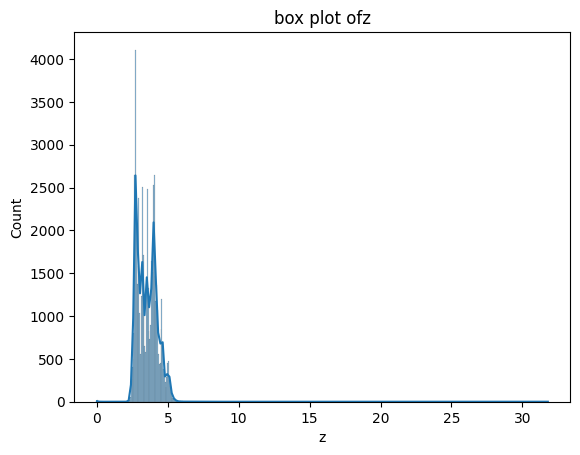

In [81]:
numerical_cols=df1.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
    sns.histplot(df1[col],kde=True)
    plt.title(f"box plot of{col}")
    plt.show()

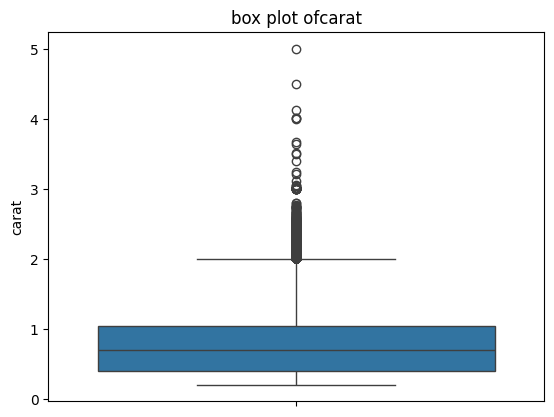

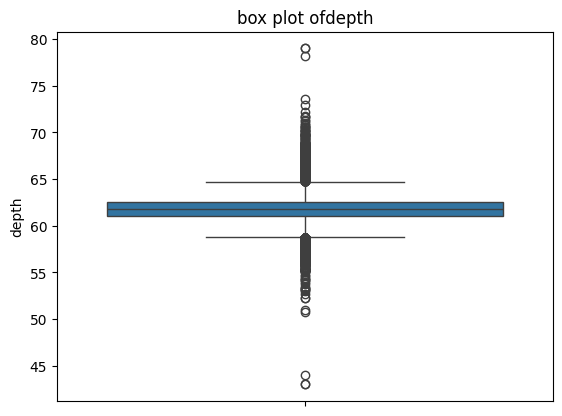

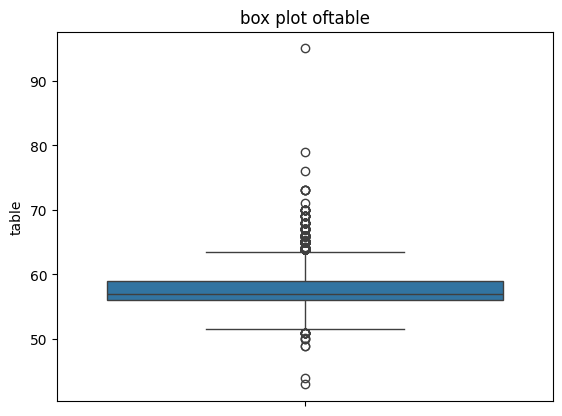

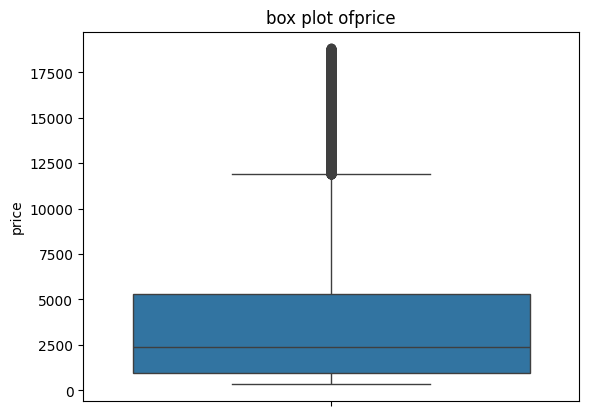

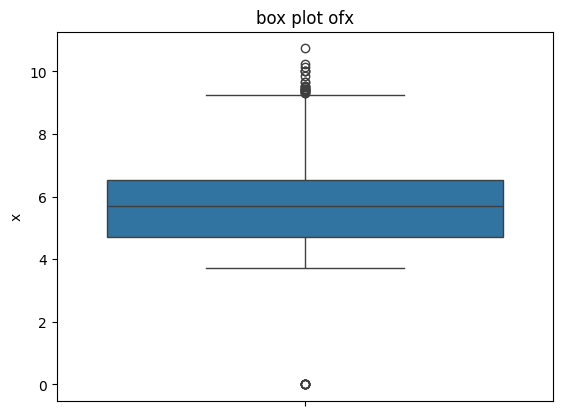

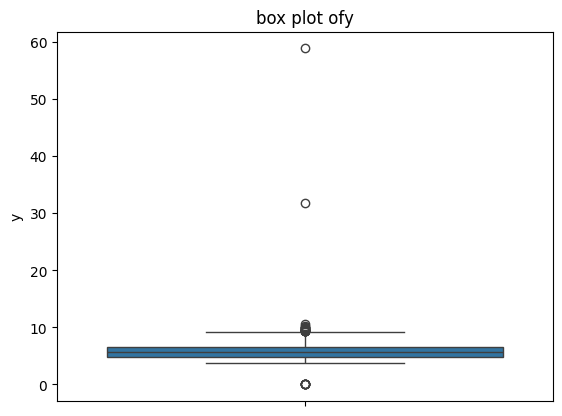

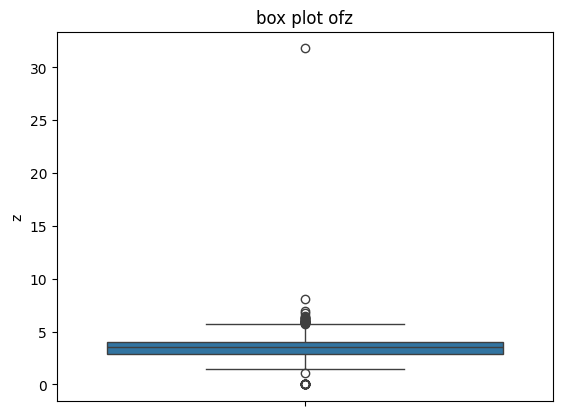

In [84]:
numerical_cols=df1.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
    sns.boxplot(df1[col])
    plt.title(f"box plot of{col}")
    plt.show()

In [85]:
df1['x'].value_counts()

,count
x,
4.37,448
4.34,437
4.33,429
4.38,428
4.32,425
...,...
8.89,1
9.36,1
10.74,1


In [86]:
df1[['x','y','z']]=df1[['x','y','z']].replace(0,np.nan)
df1.dropna(subset=['x','y','z'],inplace=True)
df1.shape

(53920, 10)

In [87]:
df1['cut'].value_counts()

,count
cut,
Ideal,21548
Premium,13780
Very Good,12081
Good,4902
Fair,1609


In [94]:
cut=['Fair','Good','Very Good','Premium','Ideal']
color=['J','I','H','G','F','E','D']
clarity=['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

In [95]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder(categories=[cut,color,clarity])
df1[['cut','color','clarity']]=oe.fit_transform(df1[['cut','color','clarity']])
df1.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3.0,5.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1.0,5.0,4.0,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3.0,1.0,3.0,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1.0,0.0,1.0,63.3,58.0,335,4.34,4.35,2.75


In [96]:
columns=['carat','depth','table','x','y','z','price']
for col in columns:
    df1[col]=np.log1p(df1[col])
df1.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.207014,4.0,5.0,1.0,4.135167,4.025352,5.789960,1.599388,1.605430,1.232560
1,0.190620,3.0,5.0,2.0,4.107590,4.127134,5.789960,1.587192,1.576915,1.196948
2,0.207014,1.0,5.0,4.0,4.058717,4.189655,5.793014,1.619388,1.623341,1.196948
3,0.254642,3.0,1.0,3.0,4.149464,4.077537,5.814131,1.648659,1.654411,1.289233
4,0.270027,1.0,0.0,1.0,4.163560,4.077537,5.817111,1.675226,1.677097,1.321756


In [97]:
x=df1.drop(columns=['price'],axis=1)
y=df1['price']

In [98]:
x

,carat,cut,color,clarity,depth,table,x,y,z
0,0.207014,4.0,5.0,1.0,4.135167,4.025352,1.599388,1.605430,1.232560
1,0.190620,3.0,5.0,2.0,4.107590,4.127134,1.587192,1.576915,1.196948
2,0.207014,1.0,5.0,4.0,4.058717,4.189655,1.619388,1.623341,1.196948
3,0.254642,3.0,1.0,3.0,4.149464,4.077537,1.648659,1.654411,1.289233
4,0.270027,1.0,0.0,1.0,4.163560,4.077537,1.675226,1.677097,1.321756
...,...,...,...,...,...,...,...,...,...
53935,0.542324,4.0,6.0,2.0,4.123903,4.060443,1.909543,1.911023,1.504077
53936,0.542324,1.0,6.0,2.0,4.160444,4.025352,1.900614,1.909543,1.528228
53937,0.530628,2.0,6.0,2.0,4.155753,4.110874,1.896119,1.899118,1.517323
53938,0.620576,3.0,2.0,1.0,4.127134,4.077537,1.967112,1.962908,1.556037


In [99]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [100]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
df1.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.207014,4.0,5.0,1.0,4.135167,4.025352,5.789960,1.599388,1.605430,1.232560
1,0.190620,3.0,5.0,2.0,4.107590,4.127134,5.789960,1.587192,1.576915,1.196948
2,0.207014,1.0,5.0,4.0,4.058717,4.189655,5.793014,1.619388,1.623341,1.196948
3,0.254642,3.0,1.0,3.0,4.149464,4.077537,5.814131,1.648659,1.654411,1.289233
4,0.270027,1.0,0.0,1.0,4.163560,4.077537,5.817111,1.675226,1.677097,1.321756


In [101]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [103]:
model=Sequential()
model.add(Input(shape=(9,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='linear'))

In [104]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae','mse','r2_score'])
learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))


Epoch 1/100
4044/4044 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 3.3836 - mae: 0.9309 - mse: 3.3836 - r2_score: -2.3071 - val_loss: 0.0345 - val_mae: 0.1253 - val_mse: 0.0345 - val_r2_score: 0.9662
Epoch 2/100
4044/4044 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0251 - mae: 0.1220 - mse: 0.0251 - r2_score: 0.9754 - val_loss: 0.0265 - val_mae: 0.1084 - val_mse: 0.0265 - val_r2_score: 0.9740
Epoch 3/100
4044/4044 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0214 - mae: 0.1132 - mse: 0.0214 - r2_score: 0.9792 - val_loss: 0.0188 - val_mae: 0.0950 - val_mse: 0.0188 - val_r2_score: 0.9816
Epoch 4/100
4044/4044 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0196 - mae: 0.1078 - mse: 0.0196 - r2_score: 0.9811 - val_loss: 0.0241 - val_mae: 0.1058 - val_mse: 0.0241 - val_r2_score: 0.9763
Epoch 5/100
4044/4044 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0226 - mae: 0.1094 - mse: 0.0226 - r2_score: 0.9779 - val_loss: 0.0193 - val_mae: 0.1052 - val_mse: 0.0193 - val_r2_score: 0.9810
Epoch 6/100
4044/40

In [106]:
loss,mae,mse,r2=model.evaluate(x_test,y_test)
print('test loss:',loss)
print('test mae:',mae)
print('test mse:',mse)
print('test r2:',r2)


422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0081 - mae: 0.0647 - mse: 0.0081 - r2_score: 0.9920
test loss: 0.008289020508527756
test mae: 0.06518224626779556
test mse: 0.008289020508527756
test r2: 0.9918733835220337


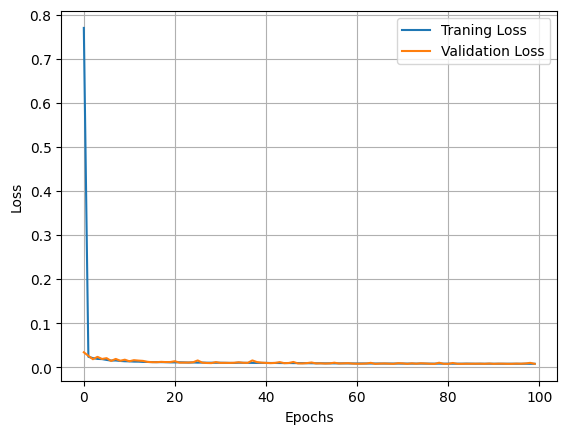

In [107]:
plt.plot(learned.history['loss'],label='Traning Loss')
plt.plot(learned.history['val_loss'],label='Validation Loss')
plt.legend()
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()